In [1]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

In [2]:
class HopfildsNetwork:
    def __init__(self):
        self.__dataset = None
        self.__weights = None

    def __call__(self, dataset):
        self.__dataset = dataset
        self.__weights = np.zeros((len(dataset[0]), len(dataset[0])))
        for pattern in self.__dataset:
            pattern = np.array(pattern).reshape(-1, 1)  # преобразование образа в столбец
            self.__weights += np.dot(pattern, pattern.T)  # инициализация весов для данного образа
        np.fill_diagonal(self.__weights, 0)  # зануляем диагональ
    def recall(self, pattern, iter=100):
        pattern_length = len(pattern)  # Длина искаженного образа
        recalled = np.array(pattern)  # Инициализация восстановленного образа
        while not (np.array_equal(self.__dataset[0], recalled) or np.array_equal(self.__dataset[1], recalled)): #not np.all(np.isin(recalled, self.__dataset)):
            for i in np.random.permutation(np.arange(pattern_length)):
                summed_input = np.dot(self.__weights[i], recalled)  # Вычисление суммы входов
                recalled[i] = np.sign(summed_input)
        #recalled = recall.reshape(-1, 10)
        return recalled

In [3]:
def PixelArray(img): #переход от цветного трехмерного массива к ч/б двумерному
    img = np.array(img)
    oz = np.zeros((10, 10))
    for i in range(img.shape[0]):
        oz[i] = [x[0] for x in img[i]]
    oz[oz == 0] = 1
    oz[oz > 1] = -1 # 255 - это белый, белый пусть будет -1
    return oz

Кот и собака

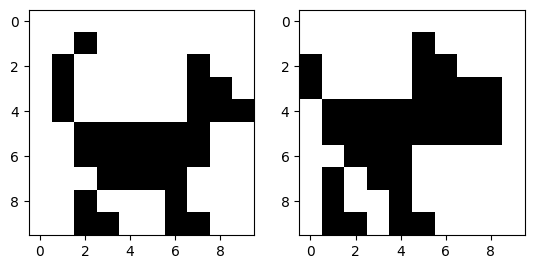

In [4]:
cat = Image.open('cat.png')
plt.subplot(1, 2, 1)
plt.imshow(cat)
dog = Image.open('dog.png')
plt.subplot(1, 2, 2)
plt.imshow(dog)
plt.show()

cat_dog = np.array([PixelArray(Image.open('cat.png')).flatten(), PixelArray(Image.open('dog.png')).flatten()])

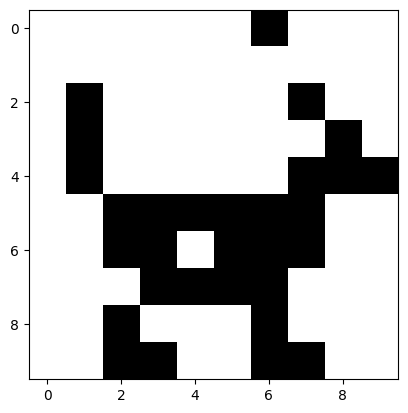

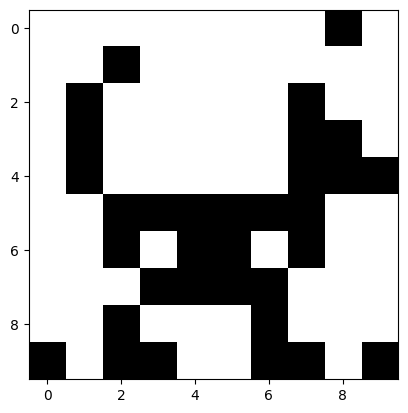

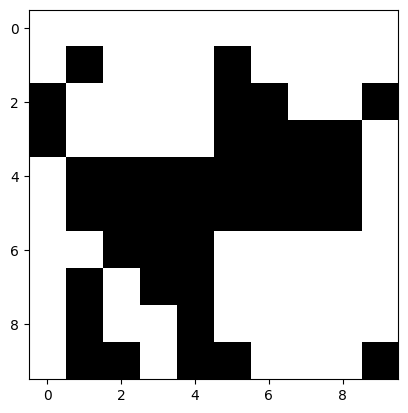

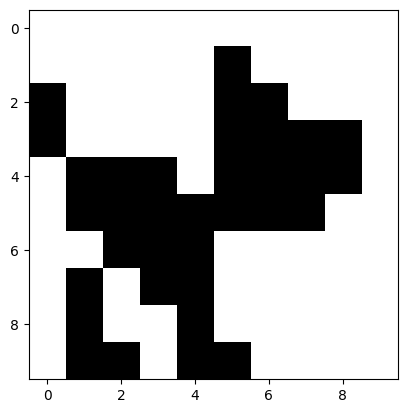

In [5]:
noisy = []
for i in range(1, 5):
  noised = Image.open(f'noised{i}.png')
  plt.imshow(noised)
  plt.show()
  noisy.append(PixelArray(noised).flatten())
noisy = np.array(noisy)

In [6]:
#to_image(cat_dog[1])
network = HopfildsNetwork()
network(cat_dog)

In [7]:
def array_to_img(array):
    a = np.array([255 if x < 0 else 0 for x in array]).reshape(-1, 10)
    img = Image.fromarray(np.uint8(a)).convert('1')
    return img

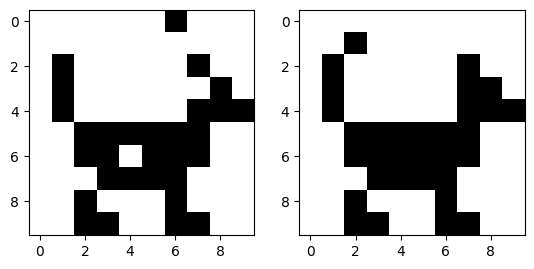

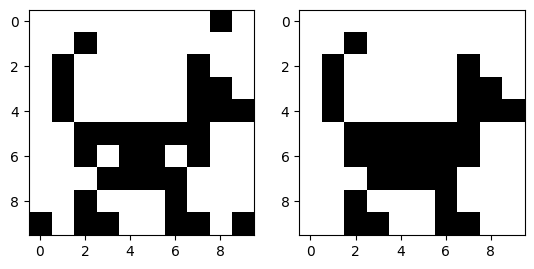

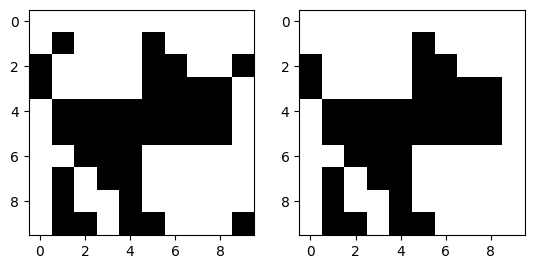

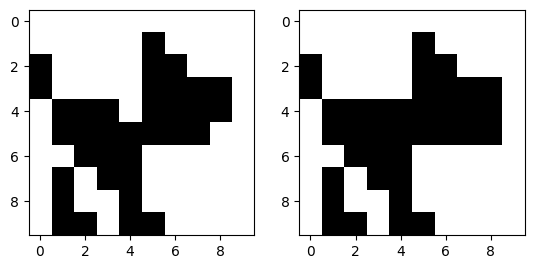

In [8]:
for i in range(len(noisy)):
    recall = network.recall(noisy[i])
    plt.subplot(1, 2, 1)
    plt.imshow(array_to_img(noisy[i]))
    plt.subplot(1, 2, 2)
    plt.imshow(array_to_img(recall))
    plt.show()